<a href="https://colab.research.google.com/github/jbeeksieu2023-del/ML-fundamentals-2026/blob/main/assignment_1_jade_beeksieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting whether the client subscribes to a term deposit**

GitHub repository: https://github.com/jbeeksieu2023-del/ML-fundamentals-2026

**Imports and helper functions needed**

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import pandas as pd
from google.colab import files

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV


!pip install scikit-optimize

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)


from sklearn.preprocessing import StandardScaler


from skopt import BayesSearchCV
sns.set_theme(style="whitegrid")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from imblearn.over_sampling import RandomOverSampler


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay


warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

In [2]:
def compute_metrics(y_true, y_pred, y_score=None):
    """Return a dict of standard classification metrics.
    y_score: predicted probabilities for the positive class (needed for ROC-AUC).
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test):
    df = pd.DataFrame({
        "Set": ["Train", "Validation", "Test"],
        "X shape": [X_train.shape, X_val.shape, X_test.shape],
        "y shape": [y_train.shape, y_val.shape, y_test.shape],
    })
    display(df.style.hide(axis="index"))


def display_metrics(name, metrics, decimals=4):
    print(f"\n{name}")
    df = pd.DataFrame([metrics]).round(decimals)
    display(df.style.hide(axis="index"))


def display_model_results(name, best_params, metrics, decimals=4):
    print(f"\n{name} — Best Parameters")
    display(pd.DataFrame([best_params]).style.hide(axis="index"))
    print(f"{name} — Validation Metrics")
    display(pd.DataFrame([metrics]).round(decimals).style.hide(axis="index"))


# Accumulator for the summary table
results_table = []

def add_result(name, split, metrics, best_params=None, notes=None):
    row = {
        "Model": name,
        "Split": split,
        "Accuracy": metrics.get("accuracy"),
        "Precision": metrics.get("precision"),
        "Recall": metrics.get("recall"),
        "F1": metrics.get("f1"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Notes": notes,
    }
    if best_params:
        row["Best Params"] = ", ".join(f"{k}={v}" for k, v in best_params.items())
    else:
        row["Best Params"] = None
    results_table.append(row)


def show_results(sort_by=("Split", "ROC-AUC"), ascending=(True, False), decimals=4):
    df = pd.DataFrame(results_table)
    if df.empty:
        print("results_table is empty.")
        return df
    df_sorted = df.sort_values(list(sort_by), ascending=list(ascending))
    display(df_sorted.round(decimals).style.hide(axis="index"))
    return df_sorted

**Task: Task Ordering**

The pipeline I propose for this task is the following:

1.   Identify prediction target.
We should inspect the columns to choose the target variable. Base it on goal of task. We should not use a target that is an outcome of something else, this can create target leakage.
2.   Data loading
Exploring the data can use all information as no changes are made. Don't fit any transformations as can lead to preprocessing leakage.
3.   Data splitting
Splitting into sets must be done before any preprocessing so that validation/test sets are not affected- preprocessing leakage. All steps after have to be done after splitting.
4.   Handling missing values
Encoders and other preprocesses usually cannot handle N/A's, and if inputed, it must be done before other steps. Can use only training sets, do not impute using the full data as it leaks information to validation/test sets.
5.   Encoding categorical values
Again, we cannot fit the encoding on data from validation/test sets, only training to avoid preprocessing leakage.
6.   Feauture scaling
We change distribution statistics here, so only on training set so that we don't leak information. Done before selecting so that decisions are on the same feauture space.
7.   Feature selection
As we compute distribution statistics , this must use only training sets as it can leak this information to the full data and inflate metrics. Must be done before scaling so we know which features to work on. Done before resampling, so that we do not resample something only to change it later.
8.   Adressing class imbalance
We can only resample our data on the training set because this can lead to preprocessing leakage. Must be addressed before logistic model so that our model can act on balanced data and our evaluation metrics are useful.
9.  Train Logistic Regression
Finally, we train our model. We train it on our training set and then evaluate its performance on the untouched validation set. Make sure not to repeat this on test set too much as it can lead to overfitting.




An incorrect approach: resampling before we split

---
This will severely affect our evaluation. The resamples can appear in both our training and our validation/test sets, and so our model will be tested on data that also appears on our training set. We won't be able to observe the difference of our model when using a balanced or inbalanced class appropiately, and our evaluation metric such as accuracy, precision and recall will no longer be valuable to us as it is likely to result in an optimistic estimate of performance.



**Task: Identifying the Prediction Target**

It is important to first diagnose the business problem, to define a goal for our model. This means that we find the **right** solution to the goal.

**"Given client and campaign information available at the time of contact, predict whether
the client subscribes to a term deposit (i.e., a type of short-term investment)."**


From our business problem formulated above, our target variable wil be the column names "y".
This column answers booleanly, yes/no, to whether or not the clients have subscribed to a term deposit. This is a clear answer to the business question, and will allow us to predict based on marketing campaigns, its success directly - yes they have commited, no they have not.
A variable which may appear as a target would be poutcome. It contains  an outcome of previous campaigns, not the current one. This is not the business goal.
Another variable could be duration. It may appear as the duration of the long-term deposit, however it is the duration of the call. Treating this as the target is incorrectly understanding what the feature represents, and it may lead to leakage as it known after or during the true prediction target is recorded.

**Task: Data Loading and Exploration**

In [3]:
files.upload()
file_path = "bank-additional.csv"
df=pd.read_csv(file_path, sep=";")

Saving bank-additional.csv to bank-additional (13).csv


In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

Number of observations (rows): 4119
Number of features (columns): 21


In [6]:
print("Data types and non-null counts:")
df.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  c

In [7]:
print("Basic summary statistics for numerical columns:")
display(df.describe())

Basic summary statistics for numerical columns:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


We can gather some basic information about the dataset now. We have 4119 rows and 21 columns. From the columns, we have split them into two data types, numerical and categorial, shown above.

Distribution of target variable 'y':


,count
y,
no,3668
yes,451


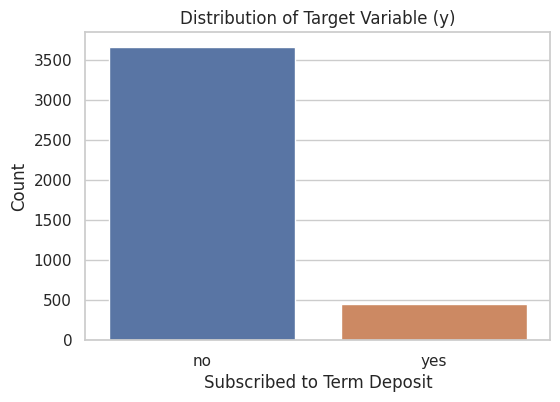


Percentage distribution of 'y':


,proportion
y,
no,89.05074
yes,10.94926


In [9]:

print("Distribution of target variable 'y':")
display(df['y'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, hue='y', legend=False)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()


class_imbalance = df['y'].value_counts(normalize=True) * 100
print("\nPercentage distribution of 'y':")
display(class_imbalance)

In [10]:

print("Explicit missing values (NaN) per column:")
display(df.isnull().sum())


print("\nImplicit missing values ('unknown') in categorical columns:")
for col in df.select_dtypes(include='object').columns:
    if 'unknown' in df[col].unique():
        print(f"  - Column '{col}': {df[col].value_counts().get('unknown', 0)} occurrences")

Explicit missing values (NaN) per column:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Implicit missing values ('unknown') in categorical columns:
  - Column 'job': 39 occurrences
  - Column 'marital': 11 occurrences
  - Column 'education': 167 occurrences
  - Column 'default': 803 occurrences
  - Column 'housing': 105 occurrences
  - Column 'loan': 105 occurrences


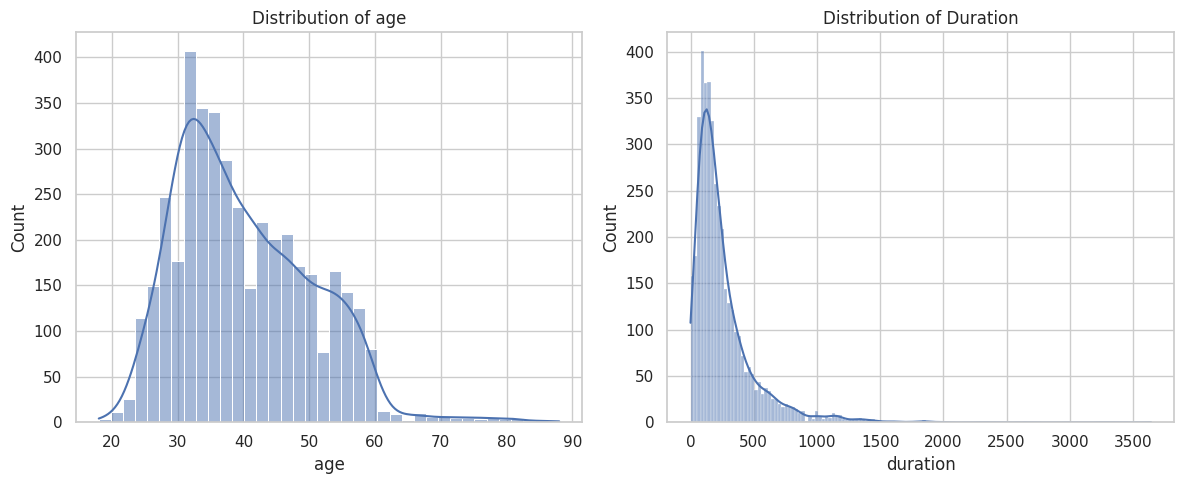

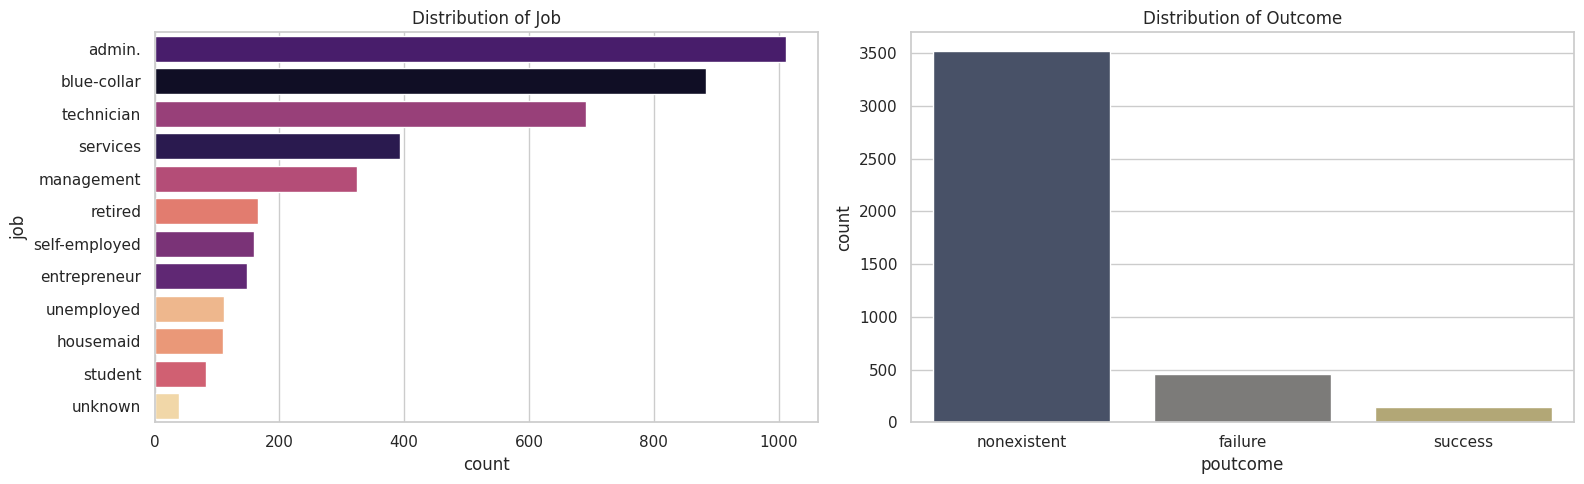

In [11]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of age')

plt.subplot(1, 2, 2)
sns.histplot(df['duration'], kde=True)
plt.title('Distribution of Duration')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='job', data=df, order=df['job'].value_counts().index, palette='magma', hue='job', legend=False)
plt.title('Distribution of Job')

plt.subplot(1, 2, 2)
sns.countplot(x='poutcome', data=df, palette='cividis', hue='poutcome', legend=False)
plt.title('Distribution of Outcome')

plt.tight_layout()
plt.show()

Given the visualisations above, duration appears to require special consideration due to its extreme right-skewness. It is also important to consider potential data leakage from the duration variable. Call duration would have been obtained after the call, meaning potentially  already knowing the clients' decision. This could be labelled as temporal leakage since the information of call duration is not available at prediction time.

The default variable has the highest unknown entries. It must be considered as potential implicit missingness, and therefore imputed or dealt with accordingly.

Also, as seen from the csv file, pdays has multiple 999 entries. The value seems to suggest it is a code instead of a numeric value, and if this is not considered - it could be very misleading. Visualising the data may help to consider best-next options, as done below.

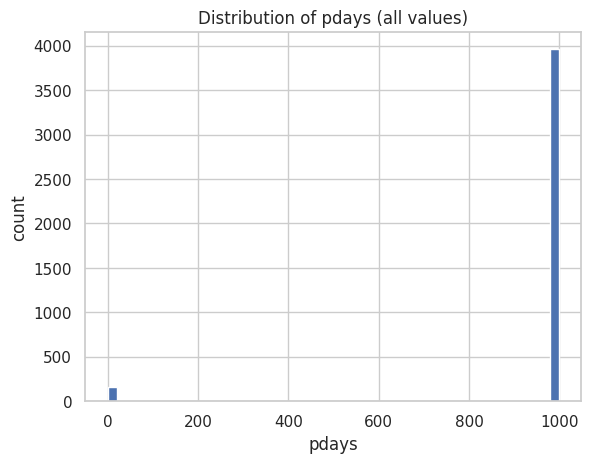

In [12]:
plt.figure()
plt.hist(df["pdays"], bins=50)
plt.title("Distribution of pdays (all values)")
plt.xlabel("pdays")
plt.ylabel("count")
plt.show()

As expected, there is a large amount of 999 entries. The distribution is heavily dominated. A visualisation of the data excluding the entry 999 may provide a more meaningful distribution, as created below.

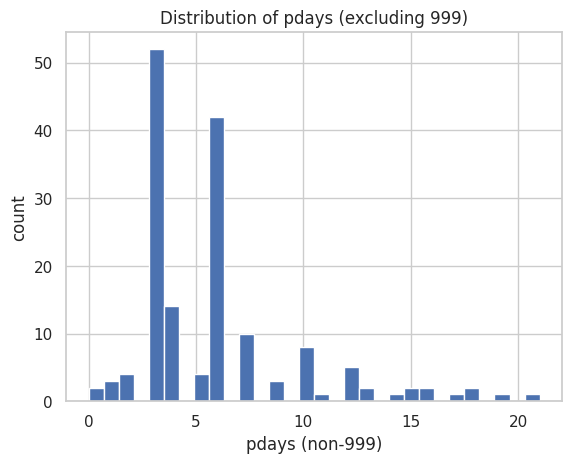

In [13]:
non_999 = df.loc[df["pdays"] != 999, "pdays"]

plt.figure()
plt.hist(non_999, bins=30)
plt.title("Distribution of pdays (excluding 999)")
plt.xlabel("pdays (non-999)")
plt.ylabel("count")
plt.show()

Results may suggest that 999 is a sentinel code, rather than a number of days since previously contacted. If we treat is as a continous variable, huge outliers will appear and the model will be biased. This variable needs to be hevaily considered, and potentially manipulated.

**Task: Data Splitting**

In [14]:

X = df.drop('y', axis=1)
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


print("Dataset splits:")
display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test)


print("\nTarget variable distribution in each split:")
print("Train set 'y' distribution:")
display(y_train.value_counts(normalize=True))
print("\nValidation set 'y' distribution:")
display(y_val.value_counts(normalize=True))
print("\nTest set 'y' distribution:")
display(y_test.value_counts(normalize=True))

y_train_bin = (y_train == "yes").astype(int)
y_val_bin   = (y_val == "yes").astype(int)
y_test_bin  = (y_test == "yes").astype(int)

Dataset splits:


Set,X shape,y shape
Train,"(2883, 20)","(2883,)"
Validation,"(618, 20)","(618,)"
Test,"(618, 20)","(618,)"



Target variable distribution in each split:
Train set 'y' distribution:


,proportion
y,
no,0.890392
yes,0.109608



Validation set 'y' distribution:


,proportion
y,
no,0.889968
yes,0.110032



Test set 'y' distribution:


,proportion
y,
no,0.891586
yes,0.108414


Since the dataset is of medium-size, the choice of split would usually range between a 80/20/20 or a 70/15/15. Using the rule of thumb that there should be 12 per class minimum, and 100 to be reliable for the validation and test sets. Since the 'y' target only has around 10% positive values, splitting them using 80/20/20 would leave the validation/test sets with only 45 positive values. Hence, the 70/15/15 splitting proportions were chosen so that our future statistics are reliable.
Since our target variable 'y' is imbalanced, approx 10% are positive, we must use stratification. Each split will have the same proportion of positive and negative values for the 'y' target variable. Our evaluation of the model therefore will mantain reliable and unbiased, which it would otherwise compromise.

**Task: Managing Missing Values**

I have already gathered explicit and implicit missing values.
There has shown to be no explicit missing values in any columns. However, implicit missing values are present in the following extent:

---
"Implicit missing values ('unknown') in categorical columns:
  - Column 'job': 39 occurrences
  - Column 'marital': 11 occurrences
  - Column 'education': 167 occurrences
  - Column 'default': 803 occurrences
  - Column 'housing': 105 occurrences
  - Column 'loan': 105 occurrences"

---




job: 39 (≈ 0.95%)

marital: 11 (≈ 0.27%)

education: 167 (≈ 4.05%)

default: 803 (≈ 19.5%)

housing: 105 (≈ 2.55%)

loan: 105 (≈ 2.55%)

Job and Marital

---


Both of these categorical variables show a low % of missingness. Since dropping these rows may risk deleting the few positive target 'y' variables that we have, we can keep them as a separate category.

Loan and Housing


---

Although these categorical variables have a moderately higher % of implicit missingness, imputing these value as "no" is assuming client financial attributes to satisfy our model and will have an impact on the predictive power and reliability of our model. These "unknown"'s remain as a separate category, too.

Education

---

This variable , for the same reasons, will keep "unknown" as a separate category.

Default

---

The "default" variable has the same fate. A missing rate so large cannot be caused by randomness, so we cannot just drop them as they may be informative in themselves. A popular imputing option would be model imputation, replacing it with the most common value, but this will have large effects on the model and remove potentially informative missingness. For this reason, we create an explicit category.

Renaming the implicit missingness of the variables above to "missing" is the data cleaning part. We ensure that missing values are represented the same way, to be  consistent across all variables. The decision to not impute, but treat this implicit missingness as separate category is a modelling decision, so that our model does not become bias due to potential removals of low positive 'y''s.

In [15]:
X_train_clean = X_train.copy()
X_val_clean   = X_val.copy()
X_test_clean  = X_test.copy()


In [16]:
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
print(f"unknown_cols defined: {unknown_cols}")

unknown_cols defined: ['job', 'marital', 'education', 'default', 'housing', 'loan']


In [17]:

for c in unknown_cols:
    for split in (X_train_clean, X_val_clean, X_test_clean):
        split[c] = split[c].replace("unknown", "missing")

Pdays

---

As mentioned before, this variable required special considerations so we review it now. Even though it does not show up in the variables with implicit missing values, we must treat 999 as a code. Due to context, it can be interpreted as the clients having no previous contact. The next step is to model this sentinel meaning. First, we should clean the column so that the entry "999" becomes a missing value, N/A.  A new boolean variable should be created, recording whether or not the client has been previously contacted or not.With N/A values in the new p_days, the logistic regression will run into issues. But if we impute these values, it is false information and does not make sense with the binary feature we have created. Eg. if we use the median, and the median is 4, the client will have been "contacted 4 days ago", but it will also say they have never been previously contacted. We can impute missing values with a value that is not in the range. In this case, it would be -1. The algorithm will then learn what to do with this value , and it also signififies no previous contact in terms of how p_days is defined. The -1 becomes the missingness indicator.

In [18]:
def add_pdays_features(X):
    X = X.copy()
    X["previously_contacted"] = (X["pdays"] != 999).astype(int)
    X["pdays_clean"] = X["pdays"].replace(999, np.nan)
    return X


In [19]:
X_train_clean = add_pdays_features(X_train_clean)
X_val_clean   = add_pdays_features(X_val_clean)
X_test_clean  = add_pdays_features(X_test_clean)


In [20]:
for X in (X_train_clean, X_val_clean, X_test_clean):
    X["pdays_clean"] = X["pdays_clean"].fillna(-1)

**Task: Encoding Categorical Variables**

In [21]:
print("Categorical columns:", cat_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


Target variable

---

As 'y' is the target predictor, we do not feature encode this variable.

Nominal variables:

---



Job
Marital
Default
Housing
Loan
Contact
Poutcome

These are all nominal variables. There is no meaningful order in their respectful categories.


Ordinal variables:

---
Education:
The order of its' categories are based on level of education. They are ordered as such:
university.degree > professional.course > high.school > basic.9y > basic.6y > basic.4y. The category called "missing" has no place in this order.

Month and day_of_week: There is chronological order here but they are not ordinal variables. If we encode them as such, the model will interpret than December (month), or Sunday (week), are far away from January (month), or Monday(week). They go in a cyclic order.




Encoding

---

Job
Marital
Default
Housing
Loan
Contact
Poutcome
. All of these nominal variables will be encoded using one-hot-encoding since they have no meaningful order to represent. One-hot coding does not create any ranks or order, hence its suitability here.


---


Education
. After consideration, although ordinal, encoding the education variable as such creates risk. It would assume that there i the same jump between each education level, which is a bold assumption. We also do not know the effect higher education will have on subscribing. Importantly, the new category "missing" does not have a position on the order of education so cannot be treated as such. One-hot encoding here will separate each education level, and the model will still be able to learn the effects that each level, independently, has on subscribing.

---


Month
Day_of_week
. Although in chronological order, its cyclical nature does not allow us to encode them with ranking or the model will misunderstand. However, sin/cos encoding could be applied. This will mantain circular distance and convert into two synthetic features.



In [22]:

MONTH_TO_IDX = {
    "jan": 0, "feb": 1, "mar": 2, "apr": 3, "may": 4, "jun": 5,
    "jul": 6, "aug": 7, "sep": 8, "oct": 9, "nov": 10, "dec": 11
}

DOW_TO_IDX = {
    "mon": 0, "tue": 1, "wed": 2, "thu": 3, "fri": 4

}

def add_cyclical_time_features(X):
    X = X.copy()


    m = X["month"].str.lower().map(MONTH_TO_IDX)
    d = X["day_of_week"].str.lower().map(DOW_TO_IDX)

    X["month_missing"] = m.isna().astype(int)
    X["dow_missing"] = d.isna().astype(int)
    m = m.fillna(0)
    d = d.fillna(0)


    month_period = 12
    dow_period = 5

    X["month_sin"] = np.sin(2 * np.pi * m / month_period)
    X["month_cos"] = np.cos(2 * np.pi * m / month_period)
    X["dow_sin"]   = np.sin(2 * np.pi * d / dow_period)
    X["dow_cos"]   = np.cos(2 * np.pi * d / dow_period)


    X = X.drop(columns=["month", "day_of_week"])

    return X


In [23]:
X_train_time = add_cyclical_time_features(X_train_clean)
X_val_time   = add_cyclical_time_features(X_val_clean)
X_test_time  = add_cyclical_time_features(X_test_clean)

X_train_time[["month_sin","month_cos","dow_sin","dow_cos"]].head()

,month_sin,month_cos,dow_sin,dow_cos
1948,-5.000000e-01,-0.866025,0.951057,0.309017
2198,1.224647e-16,-1.000000,-0.951057,0.309017
166,8.660254e-01,-0.500000,-0.951057,0.309017
2152,-8.660254e-01,0.500000,0.951057,0.309017
2881,8.660254e-01,-0.500000,0.951057,0.309017


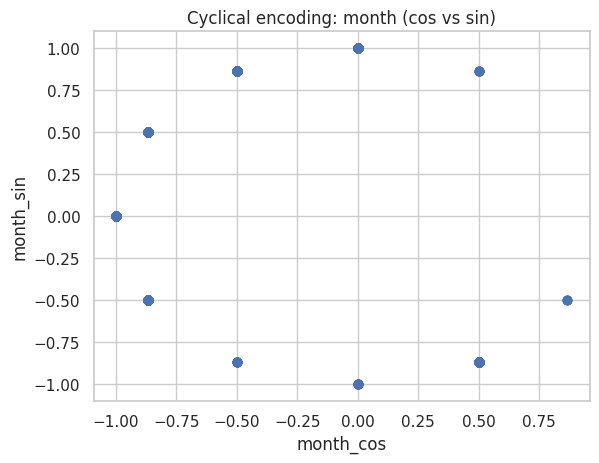

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_train_time["month_cos"], X_train_time["month_sin"], alpha=0.3)
plt.title("Cyclical encoding: month (cos vs sin)")
plt.xlabel("month_cos")
plt.ylabel("month_sin")
plt.show()

These are the only variables that do not need fitting , and can be trained to all three sets (training, test and validation). This is because the transformation of sin/cos is deterministic, and does not predict any paramaters. One-hot encoding does, however, estimate parameters so it is crucial to only fit on the training model to avoid pre processing leakage.

In [25]:
X_train_final = X_train_time.copy()
X_val_final   = X_val_time.copy()
X_test_final  = X_test_time.copy()


cat_cols = X_train_final.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train_final.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns to one-hot:", cat_cols)
print("Numerical columns passthrough:", num_cols)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)


preprocessor.fit(X_train_final)

X_train_ohe = preprocessor.transform(X_train_final)
X_val_ohe   = preprocessor.transform(X_val_final)
X_test_ohe  = preprocessor.transform(X_test_final)

ohe_fitted = preprocessor.named_transformers_["cat"]
ohe_feature_names = ohe_fitted.get_feature_names_out(cat_cols)

feature_names = list(ohe_feature_names) + num_cols

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=feature_names, index=X_train_final.index)
X_val_ohe_df   = pd.DataFrame(X_val_ohe,   columns=feature_names, index=X_val_final.index)
X_test_ohe_df  = pd.DataFrame(X_test_ohe,  columns=feature_names, index=X_test_final.index)


print("Shapes after encoding:")
print("Train:", X_train_ohe.shape)
print("Val:  ", X_val_ohe.shape)
print("Test: ", X_test_ohe.shape)

Categorical columns to one-hot: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
Numerical columns passthrough: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'pdays_clean', 'month_missing', 'dow_missing', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
Shapes after encoding:
Train: (2883, 56)
Val:   (618, 56)
Test:  (618, 56)


Changes to the dataset after encoding

---

One hot encoding changes one column of a categorical variable into 'k' columns based on the amount of categories. The dataset , as shown above, expanded to 65 features. There is now higher dimensionality. Due to this, the logistic regression will have to estimate much more coefficients. Since we do not have a very small dataset, the risk of overfitting (which normally increases by higher dimensionality) is not so high. Regularization will be applied by the logistic regression to minimise these effects, nevertheless.
The coefficients will now be interpreted differently, as a comparison to the baseline category for each variable. The intepretability is improved now due to ability to compare.
Due to encoding, the logistic regression can use string categories and contribute to different categories. We are able to see the singular effects of categories now. A linear decision boundary can now be expressed with logistic regression.



**Task: Feature Scaling**

In [26]:
def is_binary_col(s: pd.Series) -> bool:
    vals = pd.unique(s.dropna())
    return set(vals).issubset({0, 1})

scale_cols = [c for c in X_train_ohe_df.columns if not is_binary_col(X_train_ohe_df[c])]
binary_cols = [c for c in X_train_ohe_df.columns if is_binary_col(X_train_ohe_df[c])]

print("Columns to SCALE (non-binary):", scale_cols)
print("Binary columns (leave as-is):", len(binary_cols))

Columns to SCALE (non-binary): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_clean', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
Binary columns (leave as-is): 41


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train_ohe_df.copy()
X_val_scaled   = X_val_ohe_df.copy()
X_test_scaled  = X_test_ohe_df.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_ohe_df[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val_ohe_df[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test_ohe_df[scale_cols])

print("Shapes after scaling (before feature selection):")
print("Train:", X_train_scaled.shape)
print("Val:  ", X_val_scaled.shape)
print("Test: ", X_test_scaled.shape)

Shapes after scaling (before feature selection):
Train: (2883, 56)
Val:   (618, 56)
Test:  (618, 56)


The numerical values that we will scale are the continous ones. Binary variables should not be scaled as they are already one a shared scale (0/1). After we identify the continous numeric variables, they are on different ranges completely and must be scaled using standardization. Feautures means will be converted to 0, and their variance to 1. Since our variables could present many outliers, using a min/max normalization is not appropiate. Logistic regression, which we will apply, relies on the magnitude of the feautures and is sensitive to scale. Our coefficient results will be easier to compare with eachother/ more interpretable. Standardization also avoids larger gradients, due to scale, dominating the model learning the data. The regularization later applied will then be more balanced. The scale can only be fitted on the train data. The parameters we are scaling, mean and variance, are statistics that of computed on the full dataset (other sets) will lead to data leakage. After this , we can select our features.

**Task: Feature Selection**

In [28]:
print("DF shapes:", X_train_ohe_df.shape, X_val_ohe_df.shape, X_test_ohe_df.shape)

DF shapes: (2883, 56) (618, 56) (618, 56)


In [29]:
Xtr = X_train_scaled.copy()
Xva = X_val_scaled.copy()
Xte = X_test_scaled.copy()

concept_drop = []
for c in ["duration", "pdays"]:
    if c in Xtr.columns:
        concept_drop.append(c)

Xtr = Xtr.drop(columns=concept_drop, errors="ignore")
Xva = Xva.drop(columns=concept_drop, errors="ignore")
Xte = Xte.drop(columns=concept_drop, errors="ignore")

print("Conceptual drops: duration, pdays")

const_cols = [c for c in Xtr.columns if Xtr[c].nunique(dropna=False) <= 1]
print("Constant features:", len(const_cols))

def is_binary_col(s: pd.Series) -> bool:
    vals = pd.unique(s.dropna())
    return set(vals).issubset({0, 1})

binary_cols = [c for c in Xtr.columns if is_binary_col(Xtr[c])]
binary_var = Xtr[binary_cols].var()

var_thresh = 0.01
lowvar_cols = binary_var[binary_var < var_thresh].index.tolist()

print("Binary cols:", len(binary_cols))
print("Low-variance binary cols:", len(lowvar_cols))

cont_cols = [c for c in Xtr.columns if not is_binary_col(Xtr[c])]

corr_thresh = 0.95
to_drop_corr = set()

if len(cont_cols) > 1:
    corr = Xtr[cont_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = [(i, j, upper.loc[i, j])
             for i in upper.index for j in upper.columns
             if pd.notna(upper.loc[i, j]) and upper.loc[i, j] >= corr_thresh]

    print(f"Correlated pairs (|r| >= {corr_thresh}):", len(pairs))

    mean_corr = corr.mean()
    for a, b, r in pairs:
        if a not in to_drop_corr and b not in to_drop_corr:
            drop = a if mean_corr[a] > mean_corr[b] else b
            to_drop_corr.add(drop)

print("Correlated-feature drops:", len(to_drop_corr))

drop_cols = sorted(set(const_cols) | set(lowvar_cols) | set(to_drop_corr))

X_train_fs = Xtr.drop(columns=drop_cols, errors="ignore")
X_val_fs   = Xva.drop(columns=drop_cols, errors="ignore")
X_test_fs  = Xte.drop(columns=drop_cols, errors="ignore")

print("Final shapes after feature selection (and scaling/imputation):")
print("Train:", X_train_fs.shape)
print("Val:  ", X_val_fs.shape)
print("Test: ", X_test_fs.shape)

assert list(X_train_fs.columns) == list(X_val_fs.columns) == list(X_test_fs.columns)

Conceptual drops: duration, pdays
Constant features: 2
Binary cols: 41
Low-variance binary cols: 6
Correlated pairs (|r| >= 0.95): 1
Correlated-feature drops: 1
Final shapes after feature selection (and scaling/imputation):
Train: (2883, 47)
Val:   (618, 47)
Test:  (618, 47)


In [30]:
print("Non-concept Variables dropped during feature selection:", drop_cols)

Non-concept Variables dropped during feature selection: ['default_yes', 'dow_missing', 'education_illiterate', 'euribor3m', 'job_missing', 'marital_missing', 'month_missing']


Conceptual removals


---

Duration, as mentioned before, poses a leakage threat. This information is likely available at the prediction time , after a client has or has not subscribed.


Pdays is a variable that we modified so we can drop the original variable. It is redundant data.
Since one-hot encoding converted the columns into numerical arrays, these variable could not be dropped.

Low Variance removals

---
The threshold used was when variance was 0 for all features, or less than 0.01 for binary features. The threshold for binary features specifically is chosen due to p, the prevalence value. If the p value is almost 0 or almost 1, the feature is almost always going to be zero. If they are almost always zeroes , we cut the long tail so that we do not waste training time. Six binary columns were found as low variance.

High correlation removals

---

The threshold applied used Pearsons' correlation r. If r was greater than 0.95 in numerical features, we would drop them. Multicollinearity harms stability and interpretability of data when used in linear models. A high threshold is therefore valid.

Feature selection on training set only and risk of selecting features before splitting

---

Using statistics, we cannot compute them on validation nor test data. This again raises the issue of leaking information about data into those sets. We make informed decisions abotu feature selection using distributional statistics only using the training set. If we applied the wrong order, and selected features before splitting the data, our model would perform poorly because our features were chosen from data in evaluation sets instead of only from training sets.

**Task: Addressing Class Imbalance**

In [31]:

y_train_bin = (y_train == "yes").astype(int)

counts = y_train_bin.value_counts().sort_index()
props  = y_train_bin.value_counts(normalize=True).sort_index()

summary = pd.DataFrame({
    "count": counts,
    "proportion": props.round(4),
    "percent": (props * 100).round(2)
})
summary.index = ["no (0)", "yes (1)"]
summary

,count,proportion,percent
no (0),2567,0.8904,89.04
yes (1),316,0.1096,10.96


The training set is clearly imbalanced, heavily negative. 89.04% belong to negative class, y = 0, y = no. There is a clear uneven distrubition here. This is a concern for the task. A classifier can easily have a high accuracy with this data by constantly predicting the negative class, which is the majority. This is not true accuracy but may be interpreted as such.

Resampling

---

A way to manage this heavy imbalance is oversampling. Random oversampling is the most suitable choice here, as it does assumes very little about the data and only reqeights the class through duplicating.  SMOTE and ADAYSN methods generate 'pretend' points using k-nearest neighbours. Since we have used one-hot encoding on a lot of variables here, interpolation could distort the meaning of the categorical feautures. The assumptions of random resampling are minimal. It will not assume any geometric structure in feauture space, and as mentioned, will not invent new poitns between ones that already exist. It is crucial to avoid resampling before splitting the data as this can leak data into the validation and test sets, and lead to overly optimistic results in our model. Resampling must be fit to only the training set for this reason, after splitting and transforming the data but before training the logistic regression. The expected effect is that the minority class will have an increased presence in the data. the model will learn the decision boundary better , the dominated effects of the majority class on the coefficients is reduced.  

Accuracy , precision and recall

---

Class imbalance has an impact on all three of these measurements. Accuracy can be artificially high when classes are imbalanced and therefore is a misleading measurement of how the model performs.
Precision in our data, with imbalance classes, may be high as the model will rarely predict a positive. However, recall is then highly affected, as the model will not 'catch' many out of all the real positive cases. It will have learned to prioritze predicted values.

In [32]:
ros = RandomOverSampler(random_state=42)

X_train_bal, y_train_bal = ros.fit_resample(X_train_fs, y_train_bin) # Input changed to X_train_fs

print("Original training set shape:", X_train_fs.shape, y_train_bin.shape) # Print X_train_fs shape
print("Resampled training set shape:", X_train_bal.shape, y_train_bal.shape)

print("\nClass distribution after oversampling:")
display(y_train_bal.value_counts(normalize=True))

Original training set shape: (2883, 47) (2883,)
Resampled training set shape: (5134, 47) (5134,)

Class distribution after oversampling:


,proportion
y,
0,0.5
1,0.5


**Task: Training a Logistic Regression Model**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,Metric,LogReg (validation)
0,Accuracy,0.815534
1,Precision,0.328358
2,Recall,0.647059


,Metric,Zero Rule (validation)
0,Accuracy,0.889968
1,Precision,0.000000
2,Recall,0.000000


Zero Rule predicts constant class = 0 (based on ORIGINAL training majority).
Accuracy comparison: LogReg=0.8155 vs ZeroRule=0.8900


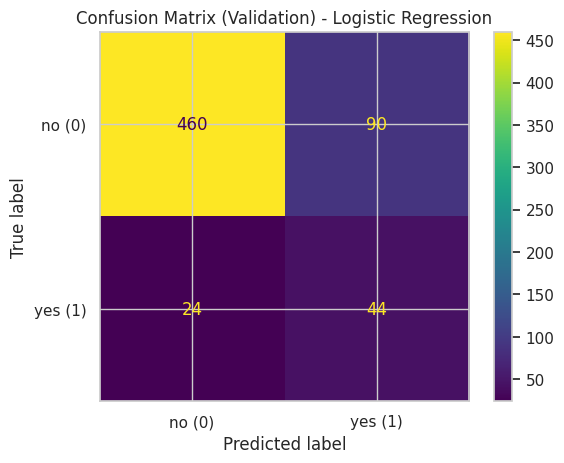

In [33]:
model = LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)
model.fit(X_train_bal, y_train_bal)


if X_val_fs.isnull().sum().sum() > 0:
    print(f"Warning: NaNs found in X_val_fs before prediction! Count: {X_val_fs.isnull().sum().sum()}")
    temp_imputer = SimpleImputer(strategy='constant', fill_value=-1)
    X_val_fs_processed = pd.DataFrame(temp_imputer.fit_transform(X_val_fs), columns=X_val_fs.columns, index=X_val_fs.index)
else:
    X_val_fs_processed = X_val_fs

y_val_pred = model.predict(X_val_fs_processed.to_numpy())


acc  = accuracy_score(y_val_bin, y_val_pred)
prec = precision_score(y_val_bin, y_val_pred, zero_division=0)
rec  = recall_score(y_val_bin, y_val_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "LogReg (validation)": [acc, prec, rec]
})
display(metrics_df)

majority_class = int(pd.Series(y_train_bin).value_counts().idxmax())
y_val_zero = np.full(shape=len(y_val_bin), fill_value=majority_class, dtype=int)

acc0  = accuracy_score(y_val_bin, y_val_zero)
prec0 = precision_score(y_val_bin, y_val_zero, zero_division=0)
rec0  = recall_score(y_val_bin, y_val_zero, zero_division=0)

baseline_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Zero Rule (validation)": [acc0, prec0, rec0]
})
display(baseline_df)

print(f"Zero Rule predicts constant class = {majority_class} (based on ORIGINAL training majority).")
print(f"Accuracy comparison: LogReg={acc:.4f} vs ZeroRule={acc0:.4f}")

cm = confusion_matrix(y_val_bin, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no (0)", "yes (1)"])

fig, ax = plt.subplots()
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix (Validation) - Logistic Regression")
plt.show()

# **Final interpretation of model**

Logistic Regression achieves 0.816 Accuracy, 0.329 Precision, and 0.647 Recall. With the Zero Rule Baseline, it achieves 0.890 Accuracy but Precision and Recall are both equal to zero. This is because it does not predict a positive class. Under class imbalance, accuracy seems great, but you can observe how it is very misleading with its' results on recall and precision. The logistic regression model detects a much more meaningful amoutn of positive classes , but then this does decrease the accuracy. There is a trade-off here between precision recall. The matrix confirms that the model predicts a lot of positive classes but there is low precision due to it being false positives at times. This is why there is a drop in accuracy in comparison to the Zero Rule. Being conducted on a resampled training set, the behaviour of our model is sensical. This verifies that our pipeline is correctly implemented.